# ARTI 403 - Image Processing
## Lab 2: Digital Image Fundamentals

ARTI403 - Image Processing
Lab 2: Digital Image Fundamentals
Outcome#1: Explain how digital images are represented and manipulated in a computer.

The manual opens '../images/lena_gray_256.tif', '../images/cameraman.tif',
'../images/A.png' and '../images/B.png'. Those files are not part of this
repository, so Step 0 builds equivalent images from skimage's built-in sample
data (plus two simple binary shapes) and writes them into ../images. Every
later step then loads them by path exactly the way the manual does.

Displaying is done with matplotlib instead of PIL's Image.show(), so the whole
lab can be run start to finish without spawning external image viewers.


In [1]:
import os
import cv2
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from PIL import Image


## Step 0: Prepare the working images on disk


In [2]:
# Paths are resolved relative to this file so the lab runs from anywhere.
# __file__ is undefined inside a notebook kernel, which starts in the notebook's
# own directory, so fall back to the working directory there.
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

IMAGES_DIR = os.path.join(HERE, "..", "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

PORTRAIT_PATH = os.path.join(IMAGES_DIR, "portrait_gray_256.png")  # stands in for lena_gray_256.tif
CAMERAMAN_PATH = os.path.join(IMAGES_DIR, "cameraman_256.png")     # stands in for cameraman.tif
A_PATH = os.path.join(IMAGES_DIR, "A.png")
B_PATH = os.path.join(IMAGES_DIR, "B.png")


def to_gray_256(image):
    """Convert a sample image to a 256x256 uint8 grayscale array."""
    if image.ndim == 3:
        image = ski.color.rgb2gray(image)
    resized = ski.transform.resize(image, (256, 256), anti_aliasing=True)
    return ski.util.img_as_ubyte(resized)


# skimage's built-in test images: astronaut() is RGB, camera() is grayscale 512x512.
ski.io.imsave(PORTRAIT_PATH, to_gray_256(ski.data.astronaut()))
ski.io.imsave(CAMERAMAN_PATH, to_gray_256(ski.data.camera()))

# Two binary shapes for the set/logical operations: a filled disk (A) and a
# filled square (B), positioned so that they partially overlap.
rows, cols = np.ogrid[:256, :256]
disk = ((rows - 100) ** 2 + (cols - 100) ** 2) <= 70 ** 2
square = (rows >= 90) & (rows < 220) & (cols >= 90) & (cols < 220)

ski.io.imsave(A_PATH, (disk * 255).astype(np.uint8))
ski.io.imsave(B_PATH, (square * 255).astype(np.uint8))


## Image Sampling and Quantization


In [3]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap="gray")
    plt.title("Sampled Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap="gray")
    plt.title("Quantized Image")
    plt.axis("off")

    plt.show()


Original shape: (256, 256)
Sampled shape (factor=14): (18, 18)
Distinct gray levels: original=255, quantized=10


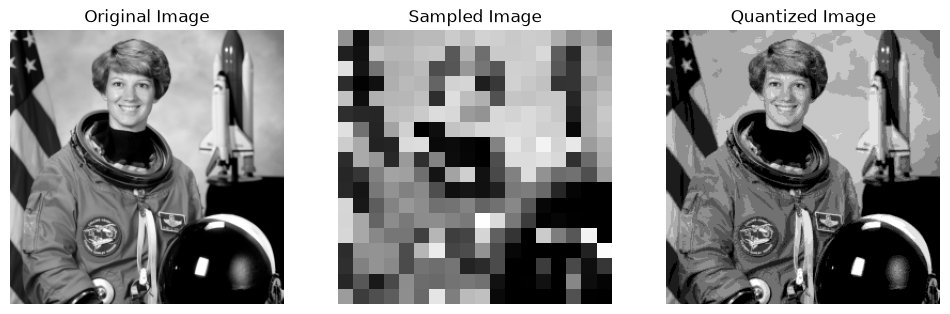

In [4]:
image_path = PORTRAIT_PATH
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

print("Original shape:", original_image.shape)
print(f"Sampled shape (factor={sampling_factor}):", sampled_image.shape)
print(
    f"Distinct gray levels: original={len(np.unique(original_image))}, "
    f"quantized={len(np.unique(quantized_image))}"
)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


## Arithmetic Operations


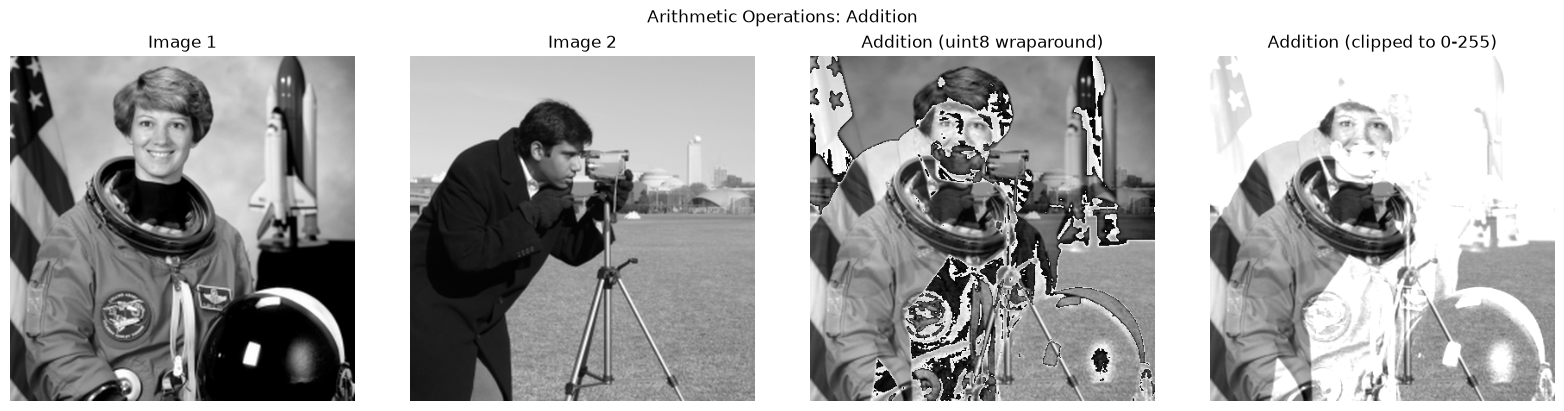

In [5]:
img1 = Image.open(PORTRAIT_PATH)
img2 = Image.open(CAMERAMAN_PATH)

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

# uint8 arithmetic wraps around: 200 + 100 becomes 44, not 255. The clipped
# version below is what we usually want when adding two images.
addition = im1arr + im2arr
addition_clipped = np.clip(im1arr.astype(np.int16) + im2arr.astype(np.int16), 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
fig.suptitle("Arithmetic Operations: Addition")
for ax, im, title in zip(
    axs,
    [im1arr, im2arr, addition, addition_clipped],
    ["Image 1", "Image 2", "Addition (uint8 wraparound)", "Addition (clipped to 0-255)"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()


## Sets and Logical Operations (binary images)


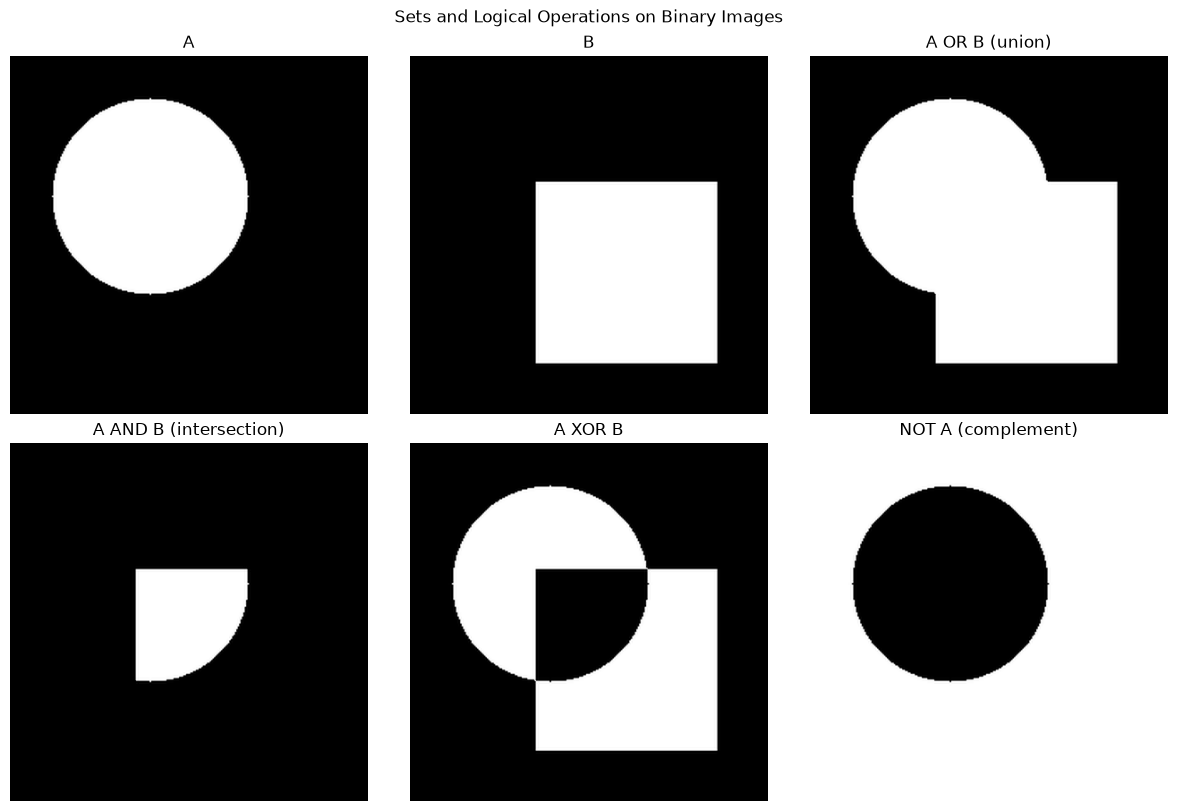

In [6]:
img3 = Image.open(A_PATH)
img4 = Image.open(B_PATH)

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
intersection = im4arr & im3arr
xor = im4arr ^ im3arr
complement_a = ~im3arr

fig, axs = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
fig.suptitle("Sets and Logical Operations on Binary Images")
for ax, im, title in zip(
    axs.ravel(),
    [im3arr, im4arr, union, intersection, xor, complement_a],
    ["A", "B", "A OR B (union)", "A AND B (intersection)", "A XOR B", "NOT A (complement)"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()


## Task #1: Change the sampling and quantization parameters and observe the effects.


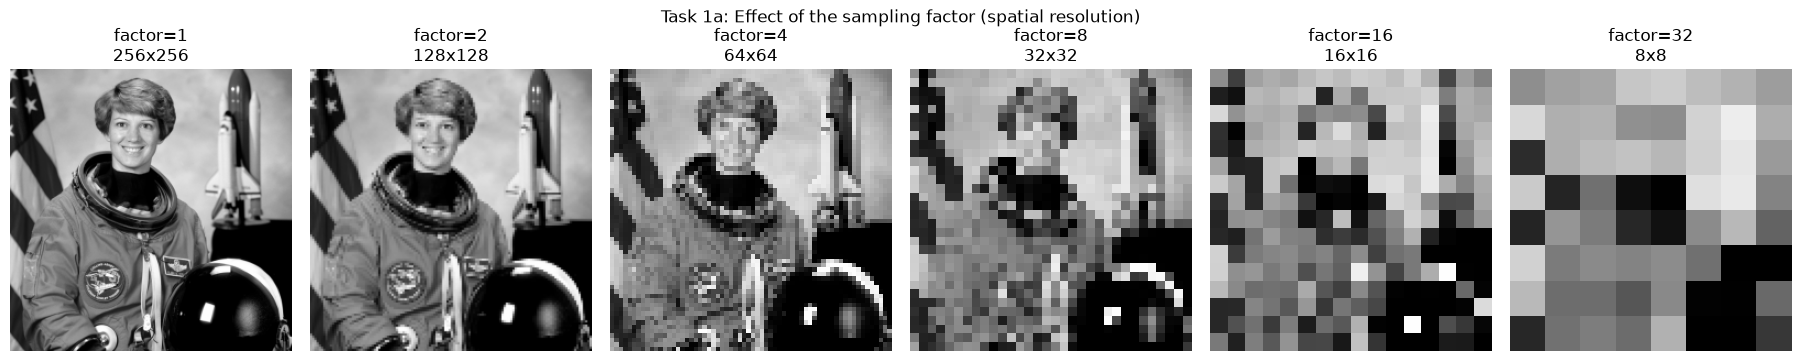

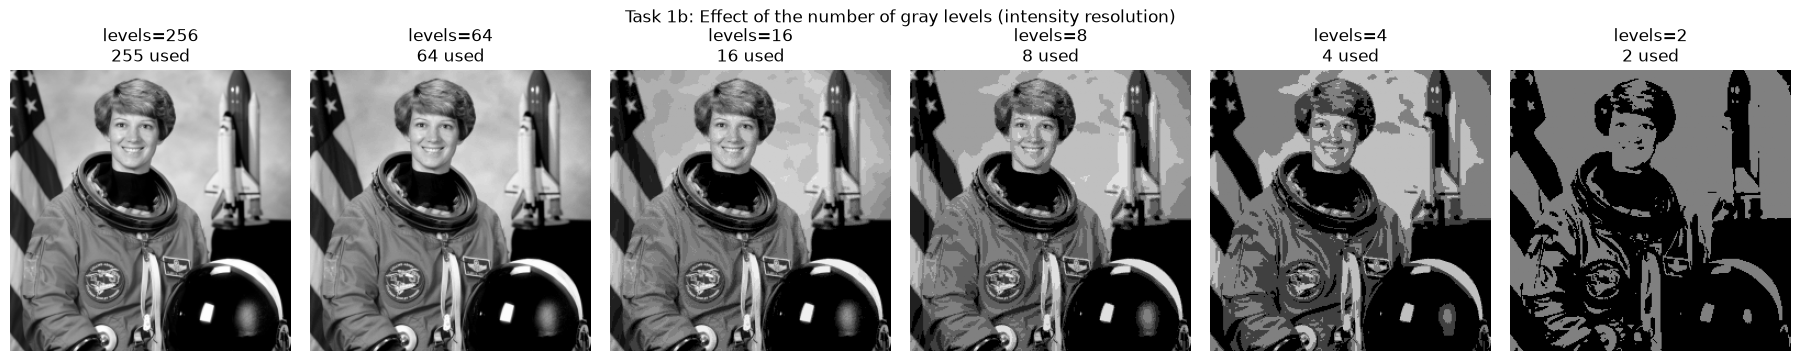


--- Task 1 observations ---
sampling factor  1: shape (256, 256),  65536 pixels
sampling factor  2: shape (128, 128),  16384 pixels
sampling factor  4: shape (64, 64),   4096 pixels
sampling factor  8: shape (32, 32),   1024 pixels
sampling factor 16: shape (16, 16),    256 pixels
sampling factor 32: shape (8, 8),     64 pixels
quantization levels 256: 255 distinct values in the result
quantization levels  64:  64 distinct values in the result
quantization levels  16:  16 distinct values in the result
quantization levels   8:   8 distinct values in the result
quantization levels   4:   4 distinct values in the result
quantization levels   2:   2 distinct values in the result


In [7]:
# Sampling: fewer samples means fewer pixels, so the image gets blockier and
# the fine detail (badge lettering, the rocket in the background) is the first
# thing to disappear.
sampling_factors = [1, 2, 4, 8, 16, 32]

fig, axs = plt.subplots(1, len(sampling_factors), figsize=(18, 3.5), layout="constrained")
fig.suptitle("Task 1a: Effect of the sampling factor (spatial resolution)")
for ax, factor in zip(axs, sampling_factors):
    sampled = sample_image(original_image, factor)
    ax.imshow(sampled, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"factor={factor}\n{sampled.shape[1]}x{sampled.shape[0]}")
    ax.axis("off")
plt.show()

# Quantization: fewer gray levels means smooth gradients break into visible
# bands - "false contouring" - which is clearly visible from about 16 levels
# down, while the spatial detail is untouched.
levels_list = [256, 64, 16, 8, 4, 2]

fig, axs = plt.subplots(1, len(levels_list), figsize=(18, 3.5), layout="constrained")
fig.suptitle("Task 1b: Effect of the number of gray levels (intensity resolution)")
for ax, levels in zip(axs, levels_list):
    quantized = quantize_image(original_image, levels)
    ax.imshow(quantized, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"levels={levels}\n{len(np.unique(quantized))} used")
    ax.axis("off")
plt.show()

print("\n--- Task 1 observations ---")
for factor in sampling_factors:
    sampled = sample_image(original_image, factor)
    print(f"sampling factor {factor:>2}: shape {sampled.shape}, {sampled.size:>6} pixels")
for levels in levels_list:
    quantized = quantize_image(original_image, levels)
    print(f"quantization levels {levels:>3}: {len(np.unique(quantized)):>3} distinct values in the result")


## Task #2: Read two images, convert them into arrays, and perform the following operations on them.


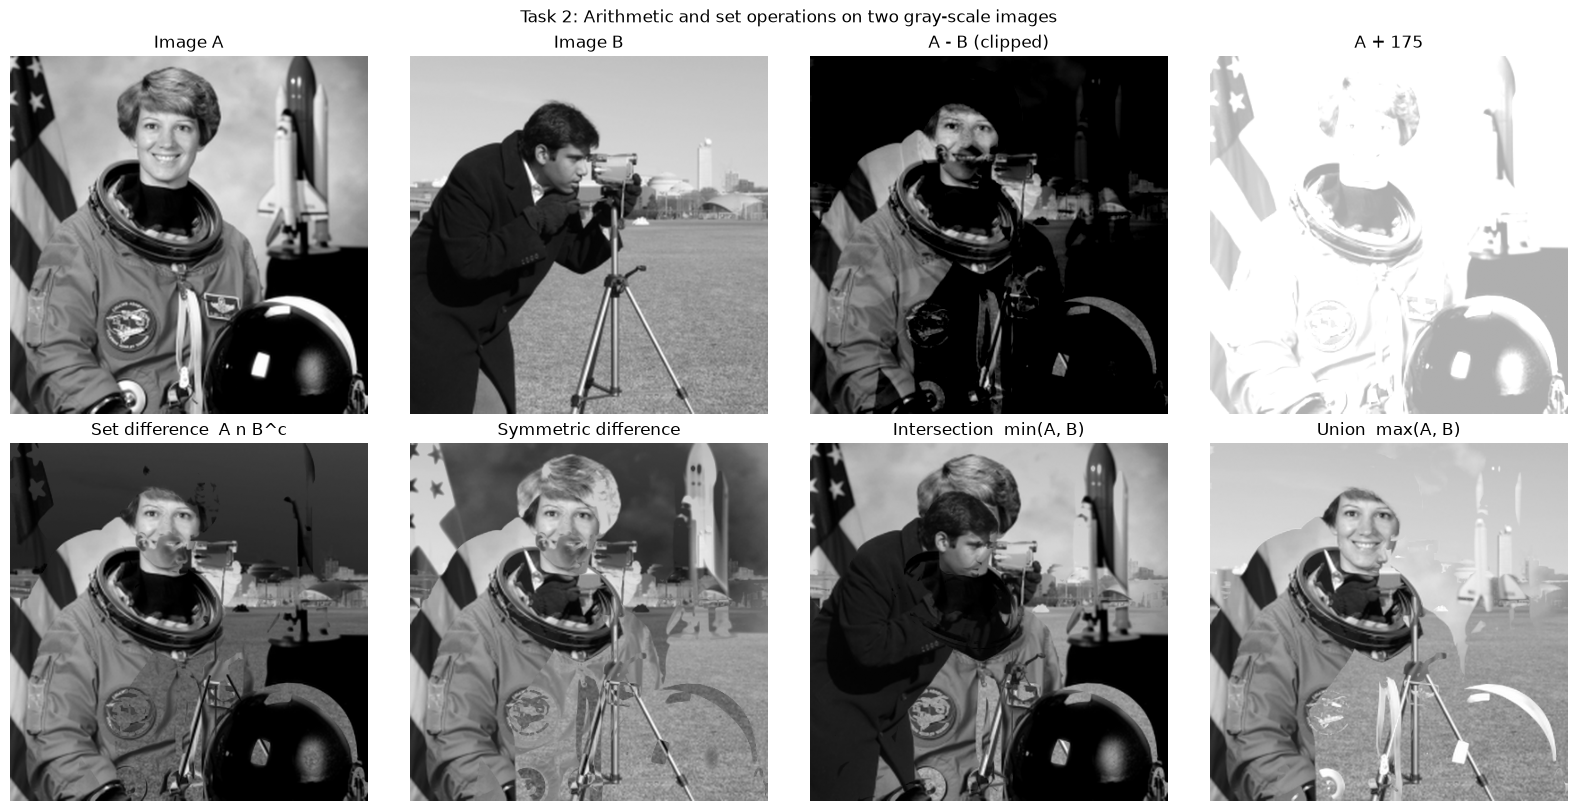


--- Task 2 results (min / max / mean of each output) ---
Image A                      min=  0  max=255  mean=112.70
Image B                      min=  0  max=255  mean=129.06
A - B (clipped)              min=  0  max=235  mean= 31.95
A + 175                      min=175  max=255  mean=235.60
Set difference  A n B^c      min=  0  max=237  mean= 71.56
Symmetric difference         min=  1  max=255  mean=119.87
Intersection  min(A, B)      min=  0  max=252  mean= 80.75
Union  max(A, B)             min=  1  max=255  mean=161.01


In [8]:
# Read the two grayscale images and convert them into arrays. Both are 400x400
# uint8, so they can be combined pixel by pixel.
a = np.asarray(Image.open(PORTRAIT_PATH).resize(resize, Image.Resampling.LANCZOS))
b = np.asarray(Image.open(CAMERAMAN_PATH).resize(resize, Image.Resampling.LANCZOS))

# Work in int16 for the arithmetic so nothing wraps around before we clip.
a16 = a.astype(np.int16)
b16 = b.astype(np.int16)

# 2.1 Subtract two images and display the result.
subtraction = np.clip(a16 - b16, 0, 255).astype(np.uint8)

# 2.2 Add one image with a constant value of 175 and display it.
add_constant = np.clip(a16 + 175, 0, 255).astype(np.uint8)

# For grayscale images the set operations are defined on intensities:
#   complement  A^c    = 255 - A
#   union       A U B  = max(A, B)
#   intersection A n B = min(A, B)
#   difference  A - B  = A n B^c = min(A, 255 - B)
complement_b = (255 - b).astype(np.uint8)

# 2.3 Set difference on two gray-scale images.
set_difference = np.minimum(a, complement_b)

# 2.4 Symmetric difference: (A - B) U (B - A).
b_minus_a = np.minimum(b, (255 - a).astype(np.uint8))
symmetric_difference = np.maximum(set_difference, b_minus_a)

# 2.5 Intersection on two gray-scale images.
gray_intersection = np.minimum(a, b)

# Shown alongside for reference: the union.
gray_union = np.maximum(a, b)

results = [
    (a, "Image A"),
    (b, "Image B"),
    (subtraction, "A - B (clipped)"),
    (add_constant, "A + 175"),
    (set_difference, "Set difference  A n B^c"),
    (symmetric_difference, "Symmetric difference"),
    (gray_intersection, "Intersection  min(A, B)"),
    (gray_union, "Union  max(A, B)"),
]

fig, axs = plt.subplots(2, 4, figsize=(16, 8), layout="constrained")
fig.suptitle("Task 2: Arithmetic and set operations on two gray-scale images")
for ax, (im, title) in zip(axs.ravel(), results):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()

print("\n--- Task 2 results (min / max / mean of each output) ---")
for im, title in results:
    print(f"{title:<28} min={im.min():>3}  max={im.max():>3}  mean={im.mean():6.2f}")
